In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === CONFIG ===
SITE_ROOT = Path(r"./csv/jennette_north")  # <-- change this
BASELINE_CSV = SITE_ROOT / "baseline2.csv"

REGIME_ROOTS = {
    # "onshore_high": SITE_ROOT / "onshore_high",
    "onshore_low": SITE_ROOT / "onshore_low",
    "offshore_high": SITE_ROOT / "offshore_high",
}
N_BASELINE_SAMPLES = 200
MIN_VALID_FRACTION = 0.9  # fraction of frames that must hit a ray for it to be "valid"


A. Build all curves + valid alongshore mask

In [2]:
def load_polyline(csv_path: Path, label: str):
    df = pd.read_csv(csv_path)
    df = df[df["label"] == label].sort_values("vertex_index")
    pts = df[["x", "y"]].to_numpy(dtype=float)
    return pts

def resample_polyline(pts: np.ndarray, n_samples: int = 200):
    seg = np.diff(pts, axis=0)
    seg_len = np.hypot(seg[:, 0], seg[:, 1])
    s = np.concatenate([[0.0], np.cumsum(seg_len)])
    total = s[-1]
    s_new = np.linspace(0, total, n_samples)
    x = np.interp(s_new, s, pts[:, 0])
    y = np.interp(s_new, s, pts[:, 1])
    return np.stack([x, y], axis=1), s_new

def compute_tangents(points: np.ndarray):
    d = np.gradient(points, axis=0)
    norms = np.linalg.norm(d, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return d / norms

def rotate90(v: np.ndarray):
    return np.stack([-v[:, 1], v[:, 0]], axis=1)

def find_any_shoreline_csv(root: Path):
    for path in root.rglob("*.csv"):
        return path
    return None

def load_shoreline(csv_path: Path):
    df = pd.read_csv(csv_path)
    df = df[df["label"] == "shoreline"].sort_values("vertex_index")
    pts = df[["x", "y"]].to_numpy(dtype=float)
    return pts

baseline_pts_raw = load_polyline(BASELINE_CSV, "baseline")
baseline_pts, baseline_s = resample_polyline(baseline_pts_raw, N_BASELINE_SAMPLES)

# normals pointing offshore
tangents = compute_tangents(baseline_pts)
normals = rotate90(tangents)

# use any shoreline to flip normals if needed
example_regime = next(iter(REGIME_ROOTS.values()))
example_csv = find_any_shoreline_csv(example_regime)
shore_example = load_shoreline(example_csv)
baseline_center = baseline_pts.mean(axis=0)
shore_center = shore_example.mean(axis=0)
vec_land_to_sea = shore_center - baseline_center
dot = np.mean(np.sum(normals * vec_land_to_sea, axis=1))
if dot < 0:
    normals = -normals

print("Baseline resampled:", baseline_pts.shape, "Normals OK:", dot >= 0)


Baseline resampled: (200, 2) Normals OK: True


In [3]:
def intersect_ray_with_segment(o, d, a, b, eps=1e-9):
    o = np.asarray(o, dtype=float)
    d = np.asarray(d, dtype=float)
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    v = b - a
    M = np.column_stack((d, -v))
    det = np.linalg.det(M)
    if abs(det) < eps:
        return None

    t, u = np.linalg.solve(M, a - o)
    if t >= -eps and -eps <= u <= 1 + eps:
        return float(t), float(u)
    return None

def compute_distances_for_shoreline(
    baseline_pts: np.ndarray,
    normals: np.ndarray,
    shoreline_pts: np.ndarray,
):
    n_base = baseline_pts.shape[0]
    dists = np.full(n_base, np.nan, dtype=float)

    seg_start = shoreline_pts[:-1]
    seg_end   = shoreline_pts[1:]
    n_seg = seg_start.shape[0]

    for i in range(n_base):
        o = baseline_pts[i]
        d = normals[i]
        best_t = None

        for j in range(n_seg):
            res = intersect_ray_with_segment(o, d, seg_start[j], seg_end[j])
            if res is None:
                continue
            t, u = res
            if t < 0:
                continue
            if best_t is None or t < best_t:
                best_t = t

        if best_t is not None:
            dists[i] = best_t

    return dists


3. Build curves for a folder + a regime

In [4]:
def list_subfolders(root: Path):
    return sorted([p for p in root.iterdir() if p.is_dir()])

def list_shoreline_csvs(folder: Path):
    return sorted(folder.glob("*.csv"))

def build_curves_for_folder(folder: Path,
                            baseline_pts: np.ndarray,
                            normals: np.ndarray):
    csv_paths = list_shoreline_csvs(folder)
    curves = []
    for path in csv_paths:
        shoreline_pts = load_shoreline(path)
        if shoreline_pts.shape[0] < 2:
            continue
        dists = compute_distances_for_shoreline(baseline_pts, normals, shoreline_pts)
        if np.all(np.isnan(dists)):
            continue
        curves.append(dists)

    if not curves:
        return None, []
    curves = np.stack(curves, axis=0)
    return curves, csv_paths

def build_curves_for_regime(regime_root: Path,
                            baseline_pts: np.ndarray,
                            normals: np.ndarray):
    all_curves = []
    folder_map = []
    subfolders = list_subfolders(regime_root)
    for sf in subfolders:
        curves, csvs = build_curves_for_folder(sf, baseline_pts, normals)
        if curves is None:
            print(f"[{regime_root.name}/{sf.name}] no valid curves.")
            continue
        all_curves.append(curves)
        folder_map.extend([(sf.name, i) for i in range(curves.shape[0])])
        print(f"[{regime_root.name}/{sf.name}] {curves.shape[0]} curves, {curves.shape[1]} samples.")
    if not all_curves:
        return None, []
    all_curves = np.concatenate(all_curves, axis=0)  # (n_frames_total, n_samples)
    return all_curves, folder_map


4. Build curves for all regimes + compute valid mask

In [5]:
regime_curves = {}
for name, root in REGIME_ROOTS.items():
    if not root.exists():
        print(f"Regime root missing: {name} -> {root}")
        continue
    curves, folder_map = build_curves_for_regime(root, baseline_pts, normals)
    if curves is None:
        continue
    regime_curves[name] = {
        "curves": curves,          # shape (n_frames, n_samples)
        "folder_map": folder_map,  # list of (folder_name, frame_idx_in_folder)
    }
    print(f"Regime {name}: total {curves.shape[0]} curves")

# compute per-regime valid mask
regime_valid_masks = {}
for name, data in regime_curves.items():
    curves = data["curves"]
    valid_fraction = (~np.isnan(curves)).mean(axis=0)  # per baseline index
    mask = valid_fraction >= MIN_VALID_FRACTION
    regime_valid_masks[name] = mask
    print(f"{name}: {mask.sum()}/{len(mask)} baseline points valid at >= {MIN_VALID_FRACTION:.2f} fraction")

# global mask: only keep indices valid in all regimes we actually have
masks = list(regime_valid_masks.values())
global_valid_mask = np.logical_and.reduce(masks)
print("Global valid baseline points:", global_valid_mask.sum(), "/", len(global_valid_mask))

baseline_s_valid = baseline_s[global_valid_mask]


[onshore_low/11] 246 curves, 200 samples.
[onshore_low/13] 95 curves, 200 samples.
[onshore_low/15] 234 curves, 200 samples.
[onshore_low/17] 467 curves, 200 samples.
[onshore_low/7] 587 curves, 200 samples.
[onshore_low/9] 495 curves, 200 samples.
Regime onshore_low: total 2124 curves
[offshore_high/11] 700 curves, 200 samples.
[offshore_high/12] 868 curves, 200 samples.
[offshore_high/13] 913 curves, 200 samples.
[offshore_high/14] 792 curves, 200 samples.
[offshore_high/15] 756 curves, 200 samples.
[offshore_high/16] 601 curves, 200 samples.
Regime offshore_high: total 4630 curves
onshore_low: 101/200 baseline points valid at >= 0.90 fraction
offshore_high: 82/200 baseline points valid at >= 0.90 fraction
Global valid baseline points: 82 / 200


B. Build functional curves (restricted to valid domain)

In [6]:
# === Build regime-specific cleaned curves (no global mask used) ===

for name, data in regime_curves.items():
    curves = data["curves"]                  # (N_frames, N_baseline_samples)
    mask = regime_valid_masks[name]          # regime-specific alongshore validity mask

    # Restrict alongshore domain
    curves_valid = curves[:, mask]           # (N_frames, N_valid_samples)

    # Drop frames containing NaNs (some rays may still fail)
    frame_valid_mask = ~np.isnan(curves_valid).any(axis=1)
    curves_valid = curves_valid[frame_valid_mask]

    # Store cleaned results
    data["curves_valid"] = curves_valid
    data["frame_valid_mask"] = frame_valid_mask
    data["baseline_mask"] = mask             # store mask for later use

    print(f"{name}: {curves.shape[0]} → {curves_valid.shape[0]} frames after NaN filtering, "
          f"{curves_valid.shape[1]} alongshore samples.")


onshore_low: 2124 → 1923 frames after NaN filtering, 101 alongshore samples.
offshore_high: 4630 → 3872 frames after NaN filtering, 82 alongshore samples.


In [7]:
# regime_curves[name]["curves_valid"]  # (n_frames_clean, n_s_valid)

C. Curve boxplots (median, envelope, outliers)

In [8]:
def functional_depth_rank(curves: np.ndarray):
    """
    Fraiman–Muniz style depth.
    curves: (N, M) -> N curves, M points alongshore
    Returns depth array of length N (higher = more central).
    """
    N, M = curves.shape
    depths = np.zeros(N, dtype=float)

    # handle NaNs just in case
    curves = np.where(np.isnan(curves), np.nanmedian(curves, axis=0, keepdims=True), curves)

    for j in range(M):
        col = curves[:, j]
        order = np.argsort(col)
        ranks = np.empty(N, dtype=int)
        ranks[order] = np.arange(N) + 1  # 1..N

        center = (N + 1) / 2.0
        denom = (N - 1) / 2.0 if N > 1 else 1.0
        U = np.abs(ranks - center) / denom  # [0, 1]
        depths += (1.0 - U)

    depths /= M
    return depths  # larger = more central


2. Boxplot construction per regime

In [9]:
def build_curve_boxplot(curves_valid: np.ndarray, baseline_s_valid: np.ndarray, name="regime"):
    N, M = curves_valid.shape
    depths = functional_depth_rank(curves_valid)

    order = np.argsort(-depths)  # deepest first
    curves_sorted = curves_valid[order]

    median_curve = curves_sorted[0]

    # central 50% region
    n_central = max(1, int(np.ceil(0.5 * N)))
    central_curves = curves_sorted[:n_central]
    lower_band = np.min(central_curves, axis=0)
    upper_band = np.max(central_curves, axis=0)

    # pointwise "IQR-like" half-width to flag outliers
    band_width = upper_band - lower_band
    # avoid zeros
    band_width = np.where(band_width == 0, np.nanmedian(band_width[band_width > 0]), band_width)

    # outlier flag: any point beyond median ± k * band_width
    k = 3
    outlier_flags = []
    for i in range(N):
        c = curves_valid[i]
        too_low  = c < (median_curve - k * band_width)
        too_high = c > (median_curve + k * band_width)
        outlier_flags.append(bool(np.any(too_low | too_high)))
    outlier_flags = np.array(outlier_flags)

    return {
        "median": median_curve,
        "lower": lower_band,
        "upper": upper_band,
        "depths": depths,
        "order": order,
        "outliers": outlier_flags,
    }

def plot_curve_boxplot(baseline_s, curves_valid, box, title, y_max=None):
    s_norm = (baseline_s - baseline_s.min()) / (baseline_s.max() - baseline_s.min())

    plt.figure(figsize=(8, 4))

    # Central 50% region
    plt.fill_between(s_norm, box["lower"], box["upper"], 
                     alpha=0.3, label="Central 50% band")

    # Median
    plt.plot(s_norm, box["median"], linewidth=2, label="Median")

    # Outliers
    outlier_indices = np.where(box["outliers"])[0]
    if len(outlier_indices) > 0:
        max_to_show = min(20, len(outlier_indices))
        for idx in outlier_indices[:max_to_show]:
            plt.plot(s_norm, curves_valid[idx], linewidth=0.7, alpha=0.4)

    plt.xlabel("Alongshore (normalized baseline coordinate)")
    plt.ylabel("Distance offshore (pixels along normal)")
    plt.title(title)
    plt.grid(True)
    plt.legend()

    # Force consistent y-axis across regimes
    if y_max is not None:
        plt.ylim(0, y_max)

    plt.tight_layout()
    plt.show()



Using Y_MAX = 1274.0
onshore_low: built boxplot for 1923 curves with 101 alongshore samples.


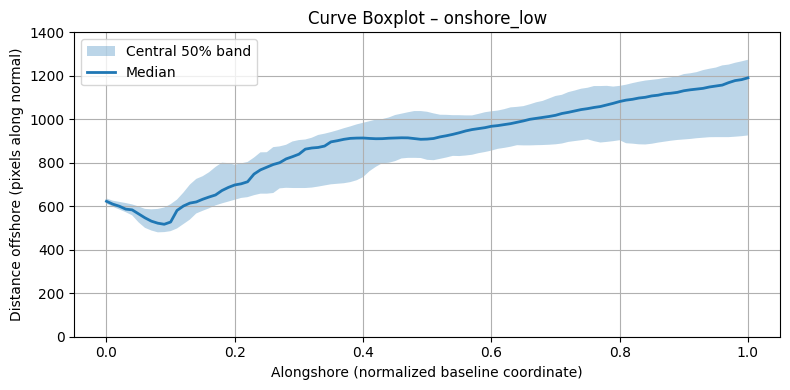

offshore_high: built boxplot for 3872 curves with 82 alongshore samples.


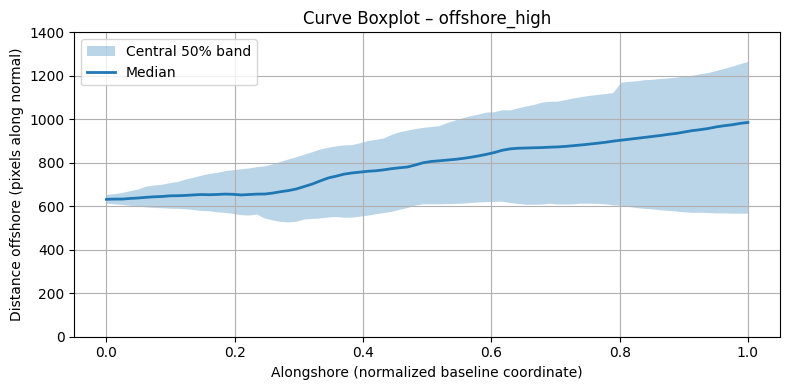

In [18]:
# === Build regime-specific cleaned curves and plot boxplots ===

regime_boxplots = {}

# Compute global Y_MAX for consistent vertical scaling
# (max distance across all regimes and frames)
all_dist_max = 0
for name, data in regime_curves.items():
    curves_raw = data["curves"]
    m = np.nanmax(curves_raw)
    if m > all_dist_max:
        all_dist_max = m

Y_MAX = all_dist_max   # e.g., ~700 based on your dataset
print("Using Y_MAX =", Y_MAX)

for name, data in regime_curves.items():
    curves = data["curves"]            # shape (N_frames, N_samples)
    mask = regime_valid_masks[name]    # regime-specific validity mask (bool array)

    # Restrict to valid alongshore domain
    curves_valid = curves[:, mask]

    # Remove frames with NaNs (some may fail to intersect on certain days)
    frame_mask = ~np.isnan(curves_valid).any(axis=1)
    curves_valid = curves_valid[frame_mask]

    # Store cleaned results back to regime_curves
    data["curves_valid"] = curves_valid
    data["frame_valid_mask"] = frame_mask
    data["baseline_mask"] = mask          # save mask for later if needed

    if curves_valid.size == 0:
        print(f"{name}: no usable curves after filtering.")
        continue

    # Infer baseline s for this regime
    baseline_s_regime = baseline_s[mask]

    # Build boxplot statistics
    box = build_curve_boxplot(
        curves_valid,
        baseline_s_regime,
        name=name
    )
    regime_boxplots[name] = box

    print(f"{name}: built boxplot for {curves_valid.shape[0]} curves with "
          f"{baseline_s_regime.shape[0]} alongshore samples.")

    # Plot with consistent y-axis
    plot_curve_boxplot(
        baseline_s_regime,
        curves_valid,
        box,
        title=f"Curve Boxplot – {name}",
        y_max=1400
    )


D. Debug visualization: overlay rays + intersections for one frame

In [20]:
def debug_rays_on_frame(baseline_pts, normals, shoreline_pts, dists,
                        ray_step=10, title="Debug rays"):
    """
    baseline_pts: (M,2)
    normals: (M,2)
    shoreline_pts: (K,2)
    dists: (M,) distances for this shoreline (same indexing as baseline_pts)
    """
    plt.figure(figsize=(7,7))

    # shoreline
    plt.plot(shoreline_pts[:,0], shoreline_pts[:,1],
             linewidth=1.5, alpha=0.8, label="Shoreline")

    # baseline
    plt.plot(baseline_pts[:,0], baseline_pts[:,1],
             color="red", linewidth=2, label="Baseline")

    # rays + intersections
    for i in range(0, baseline_pts.shape[0], ray_step):
        o = baseline_pts[i]
        d = normals[i]
        # draw ray segment of some fixed length
        L = 800  # arbitrary long
        ray_end = o + d * L
        plt.plot([o[0], ray_end[0]], [o[1], ray_end[1]],
                 linewidth=0.5, alpha=0.3)

        if not np.isnan(dists[i]):
            p_int = o + d * dists[i]
            plt.scatter(p_int[0], p_int[1], s=15, c="orange")

    plt.gca().invert_yaxis()
    plt.xlabel("Pixel X")
    plt.ylabel("Pixel Y")
    plt.title(title)
    plt.grid(True)
    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.show()


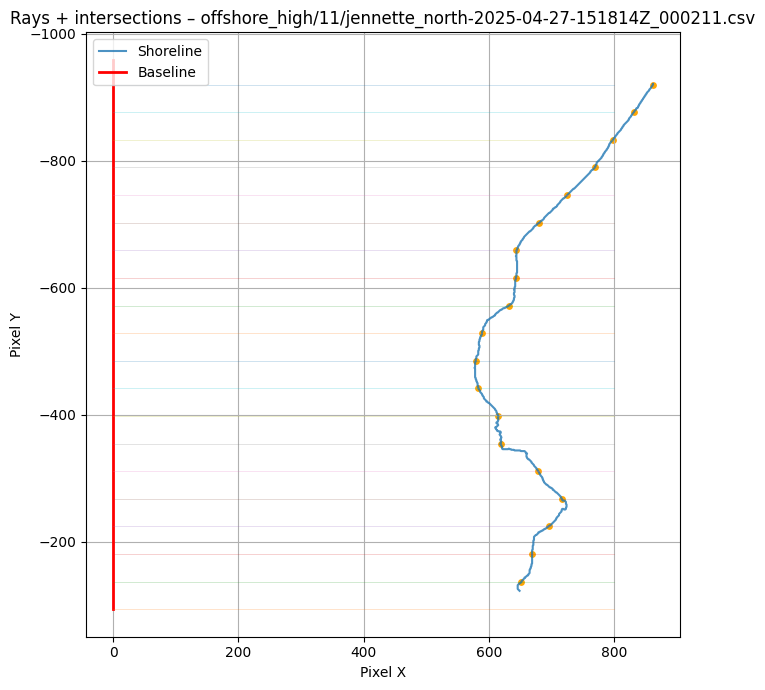

In [21]:
# pick some frame from onshore_high
reg_name = "offshore_high"
reg_root = REGIME_ROOTS[reg_name]
sf = list_subfolders(reg_root)[0]              # first subfolder, change if you want
csv_paths = list_shoreline_csvs(sf)
test_csv = csv_paths[10]                        # first frame, change index as needed

shore_pts = load_shoreline(test_csv)
dists = compute_distances_for_shoreline(baseline_pts, normals, shore_pts)

debug_rays_on_frame(
    baseline_pts=baseline_pts,
    normals=normals,
    shoreline_pts=shore_pts,
    dists=dists,
    ray_step=10,
    title=f"Rays + intersections – {reg_name}/{sf.name}/{test_csv.name}"
)


In [22]:
def debug_rays_on_frame(
    baseline_pts,
    normals,
    shoreline_pts,
    dists,
    ray_step=10,
    title="Debug rays + intersections"
):
    plt.figure(figsize=(7, 7))

    # --- shoreline ---
    plt.plot(
        shoreline_pts[:, 0],
        shoreline_pts[:, 1],
        linewidth=2,
        color="blue",
        label="Shoreline"
    )

    # --- baseline ---
    plt.plot(
        baseline_pts[:, 0],
        baseline_pts[:, 1],
        linewidth=3,
        color="red",
        label="Baseline"
    )

    # --- rays + intersections ---
    for i in range(0, baseline_pts.shape[0], ray_step):
        o = baseline_pts[i]
        d = normals[i]

        # Draw ray line (long line to visualize direction)
        L = 1000
        p_far = o + d * L
        plt.plot(
            [o[0], p_far[0]],
            [o[1], p_far[1]],
            color="gray",
            linewidth=0.6,
            alpha=0.5
        )

        # Intersection point
        if not np.isnan(dists[i]):
            p_int = o + d * dists[i]
            plt.scatter(
                p_int[0],
                p_int[1],
                color="orange",
                s=30,
                edgecolor="black",
                zorder=5
            )

    plt.gca().invert_yaxis()
    plt.legend(loc="upper left")
    plt.title(title)
    plt.xlabel("Pixel X")
    plt.ylabel("Pixel Y")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


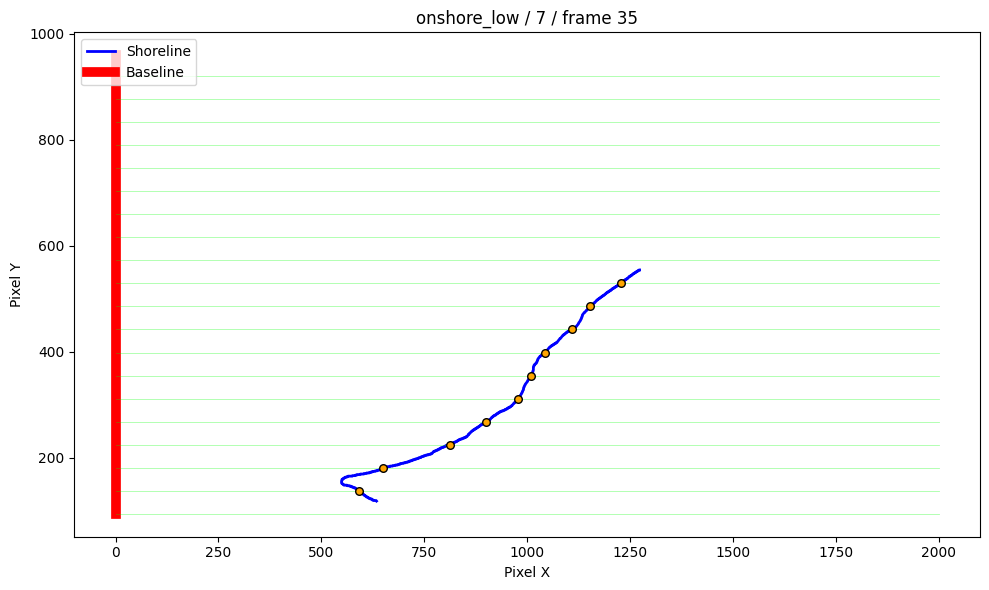

In [89]:
# Choose regime and folder
regime = "onshore_low"       # or "onshore_high"
folder_name = "7"            # example folder: "7", "10", "12", etc.
frame_idx = 35                # pick any CSV index

# Locate folder and load shoreline
reg_root = REGIME_ROOTS[regime]
folder = [sf for sf in list_subfolders(reg_root) if sf.name == folder_name][0]
csv_paths = list_shoreline_csvs(folder)

shore_pts = load_shoreline(csv_paths[frame_idx])

# Compute distances for this frame
dists = compute_distances_for_shoreline(baseline_pts, normals, shore_pts)

debug_rays_on_frame(
    baseline_pts=baseline_pts,
    normals=normals,
    shoreline_pts=shore_pts,
    dists=dists,
    ray_step=10,
    title=f"{regime} / {folder_name} / frame {frame_idx}"
)


In [85]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def debug_rays_on_frame(
    baseline_pts,
    normals,
    shoreline_pts,
    dists,
    frame_png_path=None,     # <-- new
    ray_step=10,
    title="Debug rays + intersections",
    L=2000                   # ray length
):
    # --- load image (optional) ---
    if frame_png_path is not None:
        img = mpimg.imread(frame_png_path)
        h, w = img.shape[:2]
    else:
        img = None
        h = w = None

    plt.figure(figsize=(10, 6))

    # --- draw background first ---
    if img is not None:
        plt.imshow(img, origin="upper")

    # ---- convert coords into image-space ----
    # Your CSV y range is negative, so use y_img = -y_raw
    b = baseline_pts.copy()
    s = shoreline_pts.copy()
    b[:, 1] = -b[:, 1]
    s[:, 1] = -s[:, 1]

    # normals: if they were computed in raw coords, flip their y too
    n = normals.copy()
    n[:, 1] = -n[:, 1]

    # --- shoreline ---
    plt.plot(s[:, 0], s[:, 1], linewidth=2, color="blue", label="Shoreline")

    # --- baseline ---
    plt.plot(b[:, 0], b[:, 1], linewidth=7, color="red", label="Baseline")

    # --- rays + intersections ---
    for i in range(0, b.shape[0], ray_step):
        o = b[i]
        d = n[i]

        p_far = o + d * L
        plt.plot([o[0], p_far[0]], [o[1], p_far[1]],
                 color="lime", linewidth=0.6, alpha=0.35)

        if not np.isnan(dists[i]):
            p_int = o + d * dists[i]
            plt.scatter(p_int[0], p_int[1],
                        color="orange", s=30, edgecolor="black", zorder=5)

    # --- lock axes to image bounds if available ---
    if img is not None:
        plt.xlim(0, w)
        plt.ylim(h, 0)

    plt.legend(loc="upper left", framealpha=0.8)
    plt.title(title)
    plt.xlabel("Pixel X")
    plt.ylabel("Pixel Y")
    # grid usually makes overlays uglier; keep off for paper-ish look
    # plt.grid(True)
    plt.tight_layout()
    plt.show()


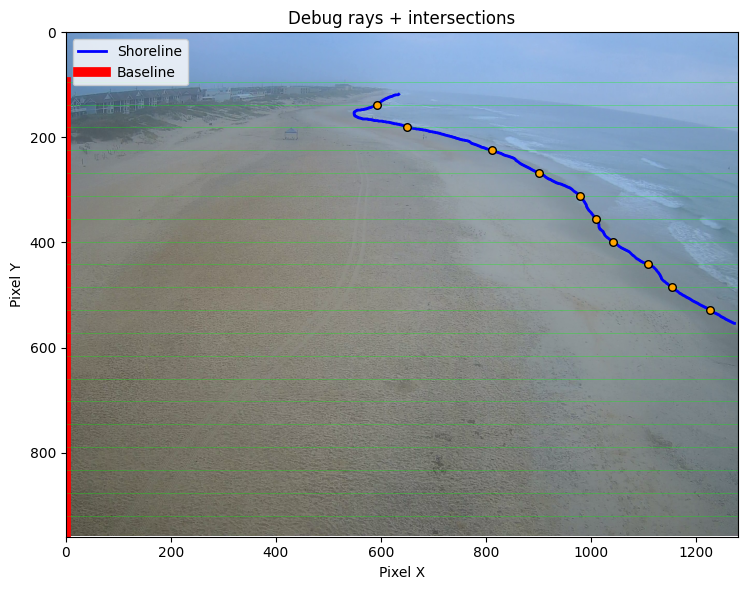

: 

In [ ]:
frame_png_path = "./jennette_pier/temp/jennette_north-2024-08-27-114451Z_000151.png"  # <-- set this

debug_rays_on_frame(
    baseline_pts=baseline_pts,
    normals=normals,
    shoreline_pts=shore_pts,
    dists=dists,
    frame_png_path=frame_png_path,
    ray_step=10,
    #title=f"{regime} / {folder_name} / frame {frame_idx}"
    #title=f"rays + intersections"
)
